# Experiment 0: Frequency-Only Baseline
**Purpose:** To verify that the frequency branch alone can classify real vs fake images above the 70% threshold before any fusion experiment is run.

## 1. Environment

In [1]:
# Imports
import sys
sys.path.insert(0, "..")   # add repo root to path
import matplotlib.pyplot as plt
from utils.fft_utils import compute_log_fft
from utils.patch_select import select_flat_patch
import torch, sys
from collections import Counter
from config import Config
from data.cifake import get_cifake_loaders
from experiments.baseline_freq_only import run_freq_only_baseline

In [2]:
print(f"Python:  {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {'cuda' if torch.cuda.is_available() else 'cpu'}")

Python:  3.12.3
PyTorch: 2.11.0+cu128
Device:  cuda


## 2. Configuration


In [3]:
cfg = Config()
cfg.data.cifake_root = "../data/raw/cifake"   
cfg.data.image_size   = 32    
cfg.data.batch_size   = 64
cfg.data.num_workers  = 4 # change to 0 if on Windows
cfg.experiment_name   = "freq_only_baseline"
cfg.notes             = "Frequency-only baseline"

print("Config ready.")
print(f"  CIFAKE root:  {cfg.data.cifake_root}")
print(f"  Image size:   {cfg.data.image_size}x{cfg.data.image_size}")
print(f"  Batch size:   {cfg.data.batch_size}")


Config ready.
  CIFAKE root:  ../data/raw/cifake
  Image size:   32x32
  Batch size:   64


## 3. Load CIFAKE

In [4]:
train_loader, test_loader = get_cifake_loaders(cfg)

# Verify dataset loaded correctly
train_n = len(train_loader.dataset)
test_n  = len(test_loader.dataset)
print(f"Train: {train_n:,} images")
print(f"Test:  {test_n:,} images")

# Show label distribution
train_labels = [label for _, label in train_loader.dataset]
counts = Counter(train_labels)
print(f"Label distribution — REAL: {counts[0]:,}  FAKE: {counts[1]:,}")

Train: 100,000 images
Test:  20,000 images
Label distribution — REAL: 50,000  FAKE: 50,000


## 4. Sanity Check

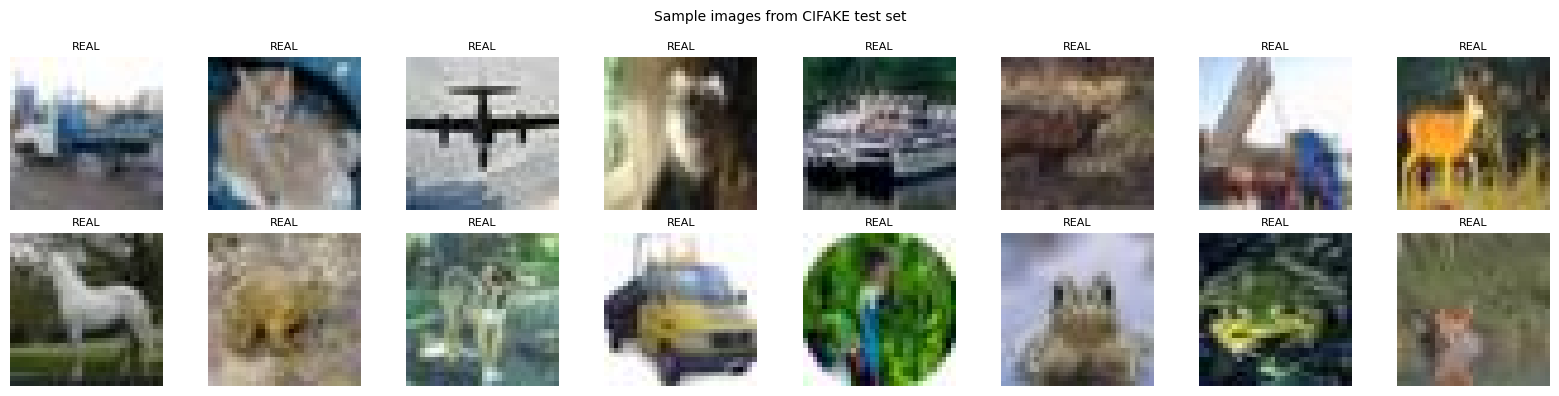

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def denorm(t):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

images, labels = next(iter(test_loader))
label_names = {0: "REAL", 1: "FAKE"}

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i >= len(images): break
    ax.imshow(denorm(images[i]).permute(1, 2, 0).numpy())
    ax.set_title(label_names[labels[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample images from CIFAKE test set", fontsize=10)
plt.tight_layout()
plt.show()


## 5. FFT Spectrum Visualisation

Verify the FFT representation looks sensible. Real and fake images should produce visibly different spectra. This is the signal the frequency branch learns from.


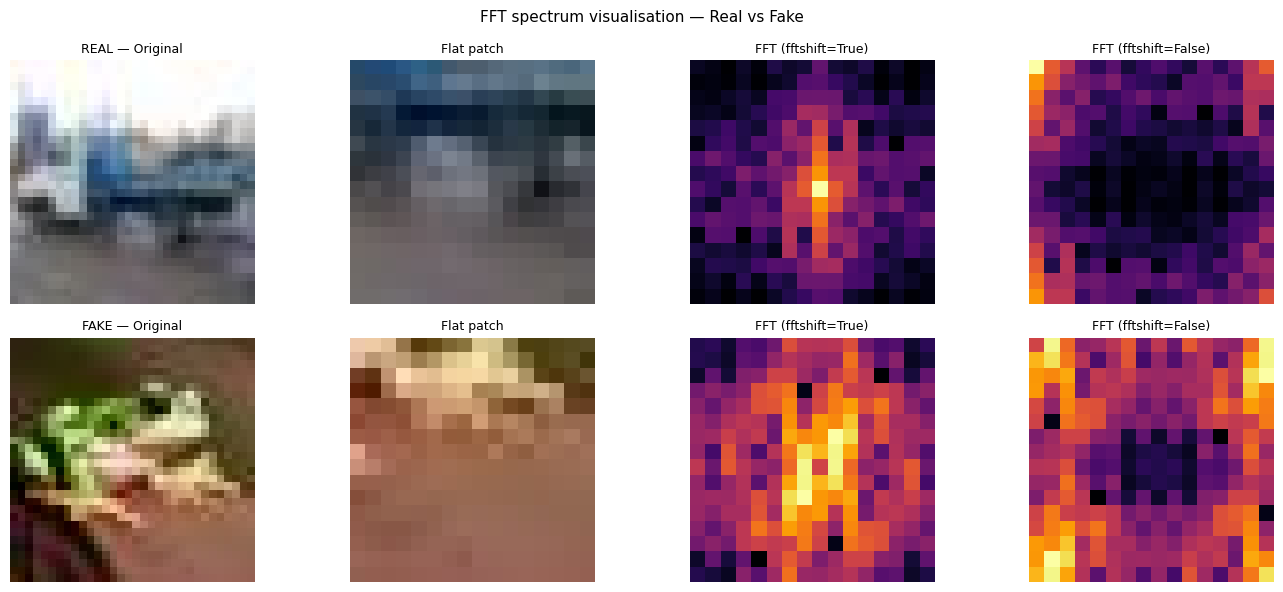

DC component should be the bright spot in the centre (fftshift=True).
Without fftshift it appears in the corners. This is what the CNN sees without the shift.


In [6]:
# Search batches until we find at least one REAL and one FAKE
real_img, fake_img = None, None
for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        if lbl.item() == 0 and real_img is None:
            real_img = img
        if lbl.item() == 1 and fake_img is None:
            fake_img = img
    if real_img is not None and fake_img is not None:
        break

if real_img is None or fake_img is None:
    print("Could not find both classes in test set — check dataset.")
else:
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for row, (img, label_str) in enumerate([(real_img, "REAL"), (fake_img, "FAKE")]):
        img_np   = denorm(img).permute(1,2,0).numpy()
        patch    = select_flat_patch(img, patch_size=min(16, 32))
        patch_np = denorm(patch).permute(1,2,0).numpy()
        gray     = patch.mean(0).numpy()
        spec_shift   = compute_log_fft(gray, fftshift=True)
        spec_noshift = compute_log_fft(gray, fftshift=False)

        axes[row][0].imshow(img_np);                       axes[row][0].set_title(f"{label_str} — Original", fontsize=9)
        axes[row][1].imshow(patch_np);                     axes[row][1].set_title("Flat patch", fontsize=9)
        axes[row][2].imshow(spec_shift,   cmap="inferno"); axes[row][2].set_title("FFT (fftshift=True)", fontsize=9)
        axes[row][3].imshow(spec_noshift, cmap="inferno"); axes[row][3].set_title("FFT (fftshift=False)", fontsize=9)
        for ax in axes[row]: ax.axis("off")

    plt.suptitle("FFT spectrum visualisation — Real vs Fake", fontsize=11)
    plt.tight_layout()
    plt.show()

    print("DC component should be the bright spot in the centre (fftshift=True).")
    print("Without fftshift it appears in the corners. This is what the CNN sees without the shift.")

## 6. Train Frequency-Only Baseline

This trains only the `FrequencyBranch` as a standalone binary classifier using its `aux_head` directly. No spatial branch, no fusion. 20 epochs should be enough to see whether the frequency signal is useful.


In [7]:
cfg.train.epochs = 20  
freq_acc = run_freq_only_baseline(
    cfg          = cfg,
    train_loader = train_loader,
    test_loader  = test_loader,
)

Device: cuda
Training frequency-only baseline for 20 epochs...
  Epoch 5/20
  Epoch 10/20
  Epoch 15/20
  Epoch 20/20

Frequency-only results:
  Accuracy: 94.6%
  AUC-ROC:  0.988
  F1:       0.947

Result: PASS — frequency branch is capturing real signal (>= 70%).
Safe to proceed to fusion experiments.
Results saved → ./results/results.csv  (freq_only_baseline, acc=0.9458)
Results saved to ./results/results.csv
